<a href="https://colab.research.google.com/github/kmsilva00/Dog_cat_classifier/blob/main/dog_cat_url_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [33]:
import tensorflow_datasets as tfds
import numpy as np # Import numpy as it's often used with tf
import tensorflow as tf # Explicitly import tensorflow

# Define image size and batch size
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Load the cats_vs_dogs dataset using tensorflow_datasets
# This handles downloading and extracting the data automatically
(train_dataset_raw, validation_dataset_raw, test_dataset_raw), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'], # Split the training data into train, validation, test
    with_info=True,
    as_supervised=True, # Returns (image, label) pairs
)

# Function to preprocess images: resize and ensure 3 channels
def preprocess_image(image, label):
    # Ensure image has a channel dimension if it's 2D
    image = tf.cond(tf.equal(tf.rank(image), 2),
                    lambda: tf.expand_dims(image, axis=-1),
                    lambda: image)

    # Explicitly set the static shape rank to 3, with dynamic dimensions.
    # This helps tf.image.resize infer its operation.
    image.set_shape([None, None, None])

    # Cast to float32 for image processing operations
    image = tf.cast(image, tf.float32)

    image = tf.image.resize(image, IMG_SIZE)
    channels = tf.shape(image)[-1]

    # Convert to 3 channels if necessary
    # Replaced tf.image.grayscale_to_rgb with explicit channel replication for robustness
    image = tf.case([
        # If 1 channel, replicate it to create 3 channels (RGB)
        (tf.equal(channels, 1), lambda: tf.concat([image, image, image], axis=-1)),
        # If >3 channels, take the first 3
        (tf.greater(channels, 3), lambda: image[:, :, :3])
    ], default=lambda: image) # If 3 channels, do nothing (default case)

    image = tf.cast(image, tf.uint8)
    return image, label

# Apply preprocessing, batching, and prefetching
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset_raw.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUTOTUNE)
validation_dataset = validation_dataset_raw.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_dataset = test_dataset_raw.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Get class names from metadata
get_label_name = metadata.features['label'].int2str
class_names = [get_label_name(i) for i in range(metadata.features['label'].num_classes)]

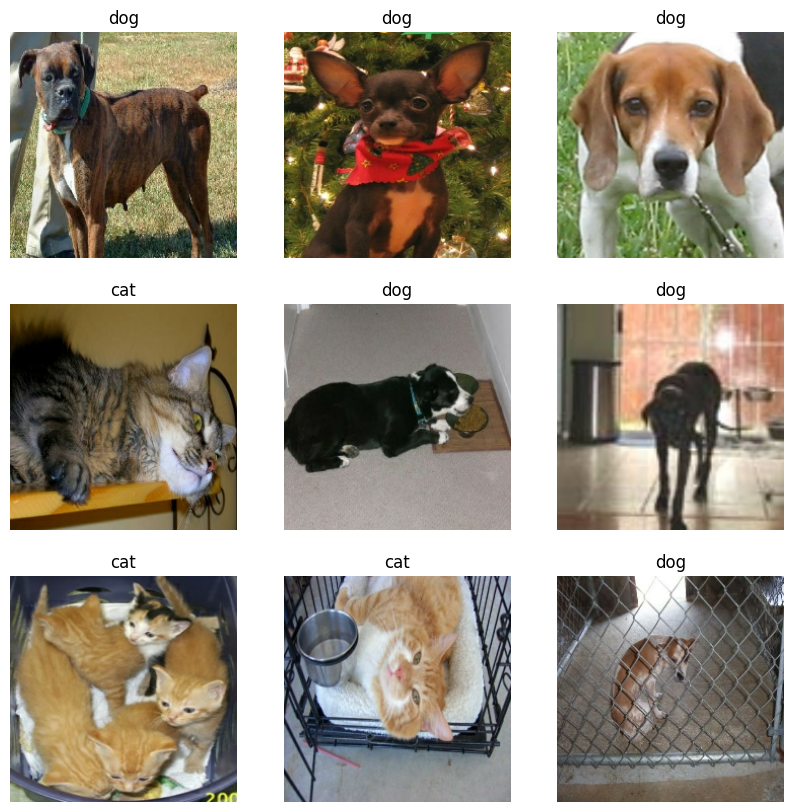

In [34]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

*Making* test set

In [35]:
#The `tfds.load` function in the previous cell already provides separate train, validation, and test datasets. Therefore, this step of re-splitting the validation dataset is no longer needed.

In [36]:
#credit for get_labels_from_tfdataset -- abhishek-bhatia stack overflow
def get_labels_from_tfdataset(tfdataset, batched=False):

    labels = list(map(lambda x: x[1], tfdataset)) # Get labels

    if not batched:
        return tf.concat(labels, axis=0) # concat the list of batched labels

    return labels

def size_dataset(dataset):
  return len(get_labels_from_tfdataset(dataset))

print("Number of test images",size_dataset(test_dataset))
print("Number of validation images",size_dataset(validation_dataset))
print("Number of train images",size_dataset(train_dataset))

print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_dataset))



Number of test images 3489
Number of validation images 3490
Number of train images 16283
Number of test batches: 110
Number of validation batches: 110
Number of train batches: 509


In [37]:
#The `prefetch` operation was already applied to `train_dataset`, `validation_dataset`, and `test_dataset` in the dataset loading cell (`JOFkTWMudrz1`). This cell is now redundant.

Augmentation on images, that will be change the images while training the model.

---



In [38]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [39]:
preprocess_input = tf.keras.applications.resnet50.preprocess_input

In [40]:
# Create the base model from the pre-trained model ResNet50
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.ResNet50(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
print(IMG_SHAPE)
print(IMG_SIZE)

(224, 224, 3)
(224, 224)


In [42]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

# 32 images, feature map = 5x5, 1280 channels per image
# convulition neural network
# the convulition nn used a 5x5 map
# and produced 1280 of those filters, features channels

(32, 7, 7, 2048)


In [43]:
base_model.trainable = False

In [44]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

global_average_layer takes the average of the 5x5 filter and outputs the average. We end up with 32 images, with 1280 values

In [45]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 2048)


prediction layer, makes the 1280 values into 1 value, sigmoid function for binary classification, 1 = dog, 0 = cat

In [46]:
prediction_layer = tf.keras.layers.Dense(1, activation='sigmoid')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 1)


we do data_augmentation on the inputs
we preprocess the inputs according to the ResNet50 model
we freeze the layers in the model ( batch normalization )
we add a dropout layer at 0.2
and we make another prediction layer.

the resulting model is saved in model has 1 output, that 1 output will, again, determine the prediction, if that value is closer to 0 then it will predict that the image is a cat, otherwise, a dog

In [47]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [48]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

freezed params = 2257984
trainable = 1281
So we successfully froze the original training model and we added some layers on top which we will train on our dataset

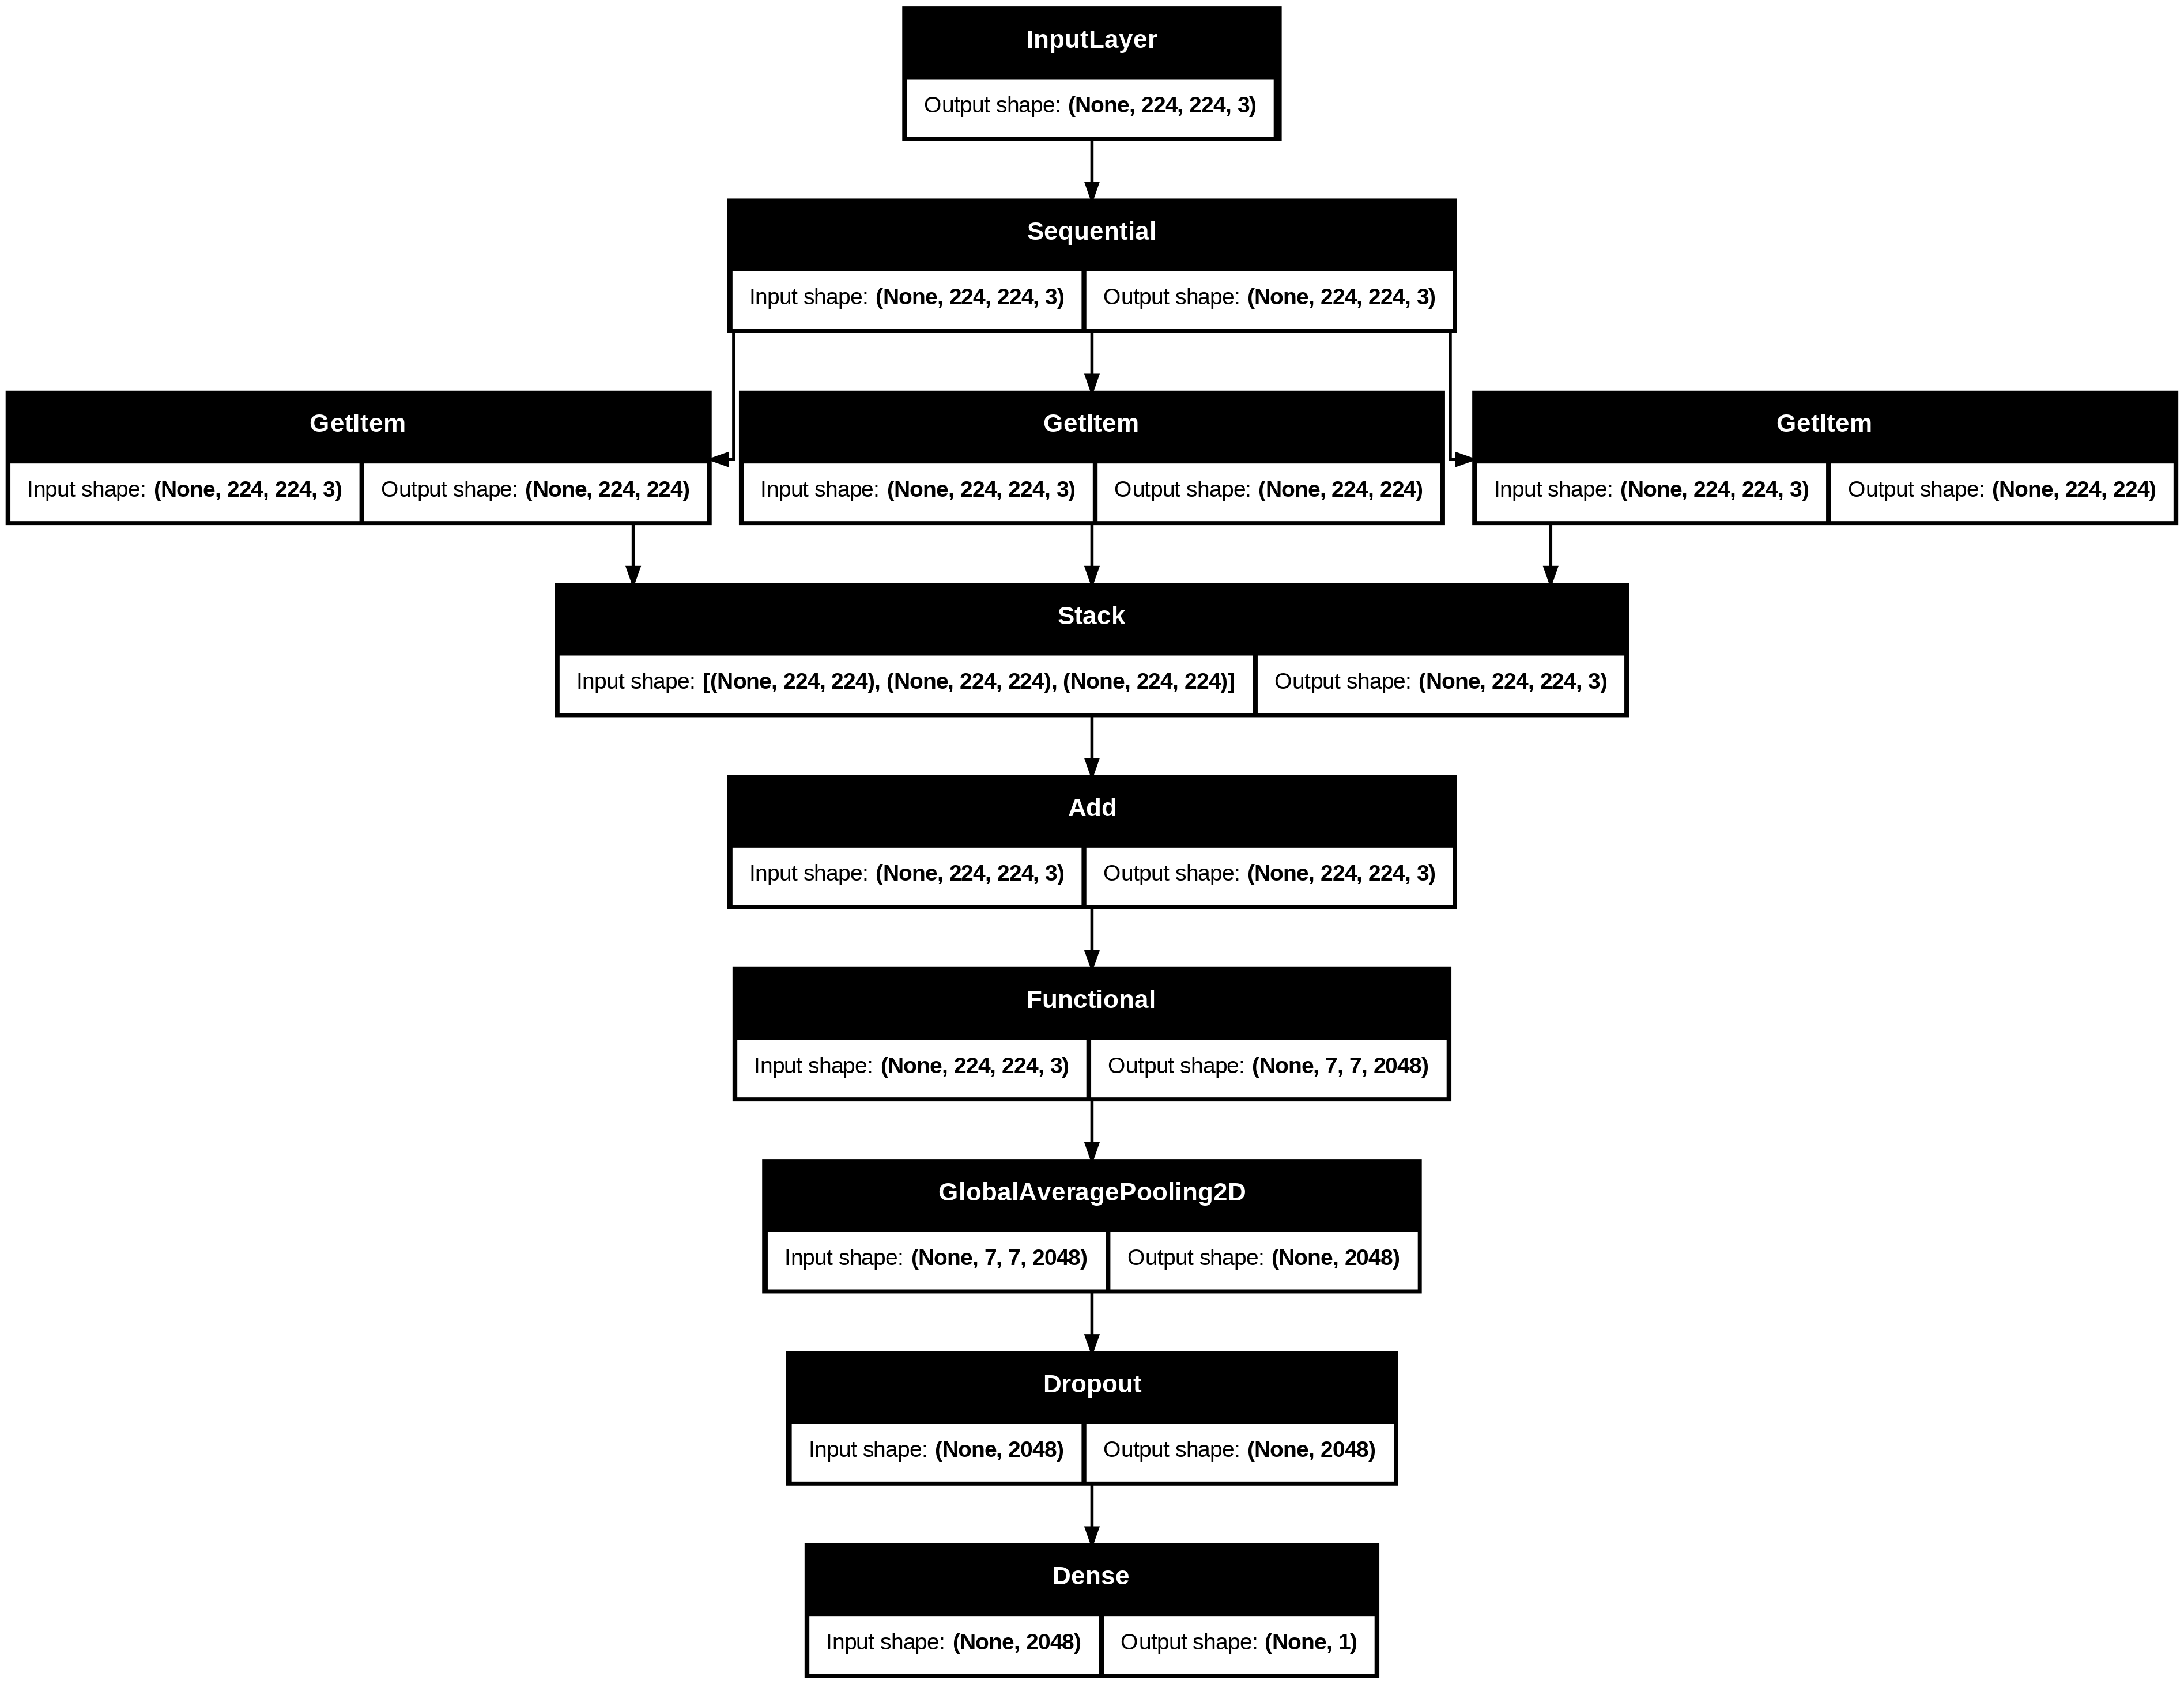

In [49]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [50]:
from tensorflow.keras.metrics import *

metrics = ['accuracy', Precision(), Recall(), AUC()]

base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=metrics)


In [51]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience = 3, monitor = 'val_loss')

In [52]:
history = model.fit(train_dataset, epochs = 15,
             validation_data=validation_dataset,
             callbacks=[es])

Epoch 1/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 101s 174ms/step - accuracy: 0.8019 - auc: 0.8669 - loss: 0.4355 - precision: 0.8109 - recall: 0.7754 - val_accuracy: 0.9739 - val_auc: 0.9960 - val_loss: 0.1008 - val_precision: 0.9595 - val_recall: 0.9897
Epoch 2/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 85s 167ms/step - accuracy: 0.9555 - auc: 0.9909 - loss: 0.1362 - precision: 0.9527 - recall: 0.9573 - val_accuracy: 0.9822 - val_auc: 0.9980 - val_loss: 0.0641 - val_precision: 0.9720 - val_recall: 0.9931
Epoch 3/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 85s 167ms/step - accuracy: 0.9633 - auc: 0.9944 - loss: 0.1023 - precision: 0.9602 - recall: 0.9656 - val_accuracy: 0.9825 - val_auc: 0.9984 - val_loss: 0.0540 - val_precision: 0.9709 - val_recall: 0.9948
Epoch 4/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 85s 167ms/step - accuracy: 0.9669 - auc: 0.9953 - loss: 0.0895 - precision: 0.9625 - recall: 0.9707 - val_accuracy: 0.9831 - val_auc: 0.9985 - val_loss: 0.0475 - val_precision: 0.9720 - val_recall: 0.9948
Epoch 5/15
509/509 

In [53]:
# Assuming you have already compiled your model and loaded the validation dataset
# (model and validation_dataset)

# Evaluate the model on the validation dataset
results = model.evaluate(validation_dataset)

# Unpack the results into separate variables
loss_value, accuracy_value, precision_value, recall_value, auc_value = results

# Print the extracted metric values
print(f"Loss: {loss_value:.4f}")
print(f"Accuracy: {accuracy_value:.4f}")
print(f"Precision: {precision_value:.4f}")
print(f"Recall: {recall_value:.4f}")
print(f"AUC: {auc_value:.4f}")


110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - accuracy: 0.9854 - auc: 0.9992 - loss: 0.0349 - precision: 0.9775 - recall: 0.9933
Loss: 0.0341
Accuracy: 0.9860
Precision: 0.9786
Recall: 0.9937
AUC: 0.9990


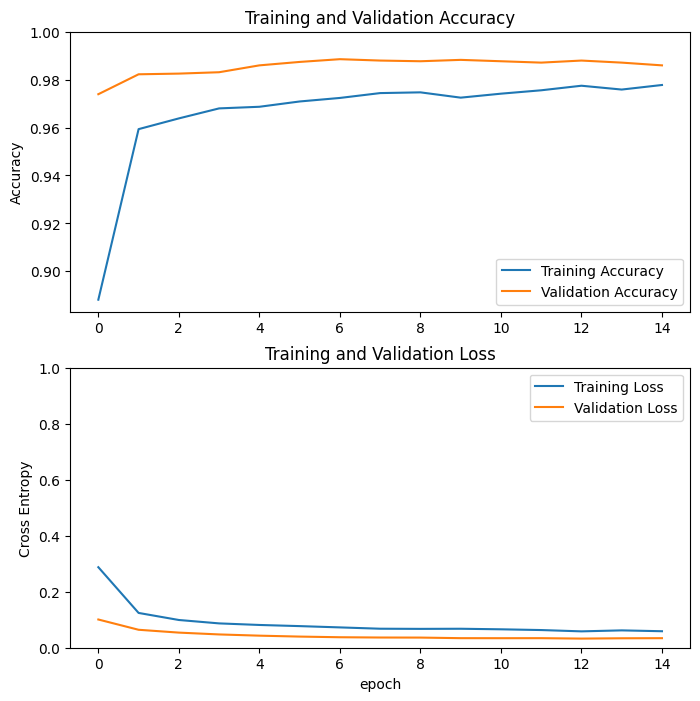

In [54]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [68]:
# Use the fetch_and_predict_image function with a working cat image URL
cat_image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg" # A new working cat image URL
fetch_and_predict_image(cat_image_url, model)

Error fetching or processing the image: HTTP Error 403: Forbidden


In [69]:
#The `fetch_and_predict_image` function definition has been moved to the cells where it is used to ensure it is always available. This cell is now redundant.

In [70]:
fetch_and_predict_image("https://www.southernliving.com/thmb/WHH7cdFT3YMJlJN4y7y3lsAKvJ8=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/gettyimages-114166947-1-268128f97e5c415baede328c1fe32f55.jpg", model)


Error fetching or processing the image: HTTP Error 403: Forbidden


In [71]:
fetch_and_predict_image("https://cdn.mos.cms.futurecdn.net/ASHH5bDmsp6wnK6mEfZdcU.jpg", model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction value: 0.9951 (dog)


In [72]:
fetch_and_predict_image("https://cdn.britannica.com/34/235834-050-C5843610/two-different-breeds-of-cats-side-by-side-outdoors-in-the-garden.jpg", model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction value: 0.0003 (cat)


In [73]:
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

prediction_list = list()
for prediction in predictions:
  if prediction <0.5:
    prediction_list.append(0)
  elif prediction >=0.5:
    prediction_list.append(1)
  else:
    prediction_list.append("n")

prediction_batch = np.asarray(prediction_list)

# Print the result
print(label_batch)
print(prediction_batch)

[0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0]
[0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0]


Fine tuning

#Fine tuning


In [74]:
base_model.trainable = True

In [75]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  175


In [76]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=metrics)

In [77]:
# Assuming you have already compiled your model and loaded the validation dataset
# (model and validation_dataset)

# Evaluate the model on the validation dataset
results = model.evaluate(validation_dataset)

# Unpack the results into separate variables
loss_value, accuracy_value, precision_value, recall_value, auc_value = results

# Print the extracted metric values
print(f"Loss: {loss_value:.4f}")
print(f"Accuracy: {accuracy_value:.4f}")
print(f"Precision: {precision_value:.4f}")
print(f"Recall: {recall_value:.4f}")
print(f"AUC: {auc_value:.4f}")


110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.9854 - auc: 0.9990 - loss: 0.0349 - precision: 0.9782 - recall: 0.9936
Loss: 0.0341
Accuracy: 0.9860
Precision: 0.9786
Recall: 0.9937
AUC: 0.9990


In [78]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 19,454,977 (74.21 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

In [79]:
len(model.trainable_variables)

92

In [80]:
history_fine = model.fit(train_dataset,
                         epochs=30,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 16/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 165s 292ms/step - accuracy: 0.9600 - auc: 0.9943 - loss: 0.1002 - precision: 0.9515 - recall: 0.9685 - val_accuracy: 0.9903 - val_auc: 0.9990 - val_loss: 0.0291 - val_precision: 0.9903 - val_recall: 0.9903
Epoch 17/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 141s 277ms/step - accuracy: 0.9806 - auc: 0.9980 - loss: 0.0537 - precision: 0.9818 - recall: 0.9787 - val_accuracy: 0.9917 - val_auc: 0.9988 - val_loss: 0.0286 - val_precision: 0.9903 - val_recall: 0.9931
Epoch 18/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 141s 277ms/step - accuracy: 0.9858 - auc: 0.9988 - loss: 0.0390 - precision: 0.9851 - recall: 0.9860 - val_accuracy: 0.9923 - val_auc: 0.9986 - val_loss: 0.0262 - val_precision: 0.9903 - val_recall: 0.9943
Epoch 19/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 141s 278ms/step - accuracy: 0.9889 - auc: 0.9990 - loss: 0.0321 - precision: 0.9887 - recall: 0.9889 - val_accuracy: 0.9926 - val_auc: 0.9986 - val_loss: 0.0255 - val_precision: 0.9909 - val_recall: 0.9943
Epoch 20/30


In [81]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

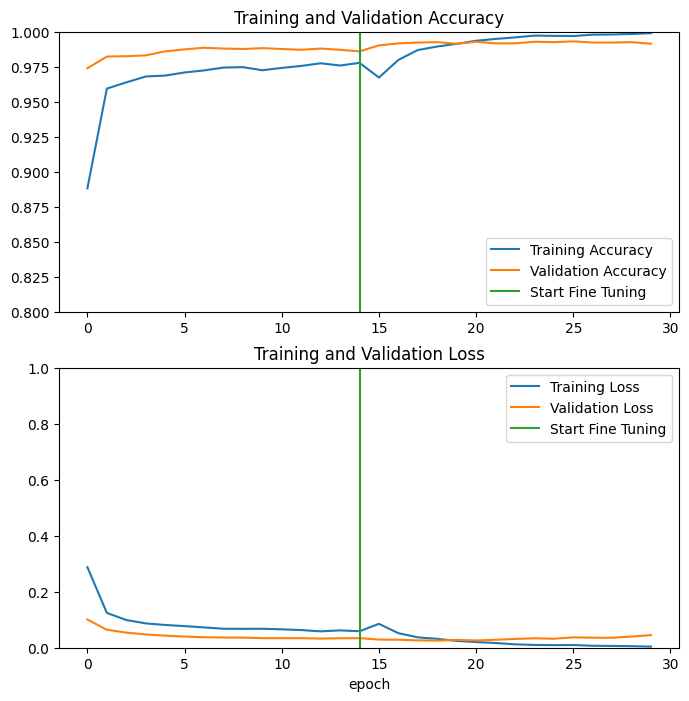

In [82]:
initial_epochs = 15

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [83]:
# Assuming you have already compiled your model and loaded the validation dataset
# (model and validation_dataset)

# Evaluate the model on the validation dataset
results = model.evaluate(validation_dataset)

# Unpack the results into separate variables
loss_value, accuracy_value, precision_value, recall_value, auc_value = results

# Print the extracted metric values
print(f"Loss: {loss_value:.4f}")
print(f"Accuracy: {accuracy_value:.4f}")
print(f"Precision: {precision_value:.4f}")
print(f"Recall: {recall_value:.4f}")
print(f"AUC: {auc_value:.4f}")


110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - accuracy: 0.9917 - auc: 0.9980 - loss: 0.0390 - precision: 0.9887 - recall: 0.9946
Loss: 0.0450
Accuracy: 0.9914
Precision: 0.9881
Recall: 0.9948
AUC: 0.9975


In [84]:
# Definition of fetch_and_predict_image (moved here to ensure it's defined before use)
def fetch_and_predict_image(url, model):
    try:
        # Fetch the image from the provided URL
        urllib.request.urlretrieve(url, "temp_image.jpg")

        # Open the image and resize it to the desired shape
        image = Image.open("temp_image.jpg")
        image = image.resize((224, 224))

        # Convert the image to a NumPy array
        img_array = np.asarray(image)

        # Reshape the array to match the expected input shape
        img_array = img_array.reshape((1, 224, 224, 3))

        # Make a prediction using the model
        prediction = model.predict(img_array)

        # Determine the class (cat or dog) based on the prediction
        if prediction < 0.5:
            class_label = "cat"
        else:
            class_label = "dog"

        # Print the prediction value (float between 0 and 1)
        print(f"Prediction value: {prediction[0][0]:.4f} ({class_label})")

    except Exception as e:
        print(f"Error fetching or processing the image: {e}")

fetch_and_predict_image("https://www.southernliving.com/thmb/WHH7cdFT3YMJlJN4y7y3lsAKvJ8=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/gettyimages-114166947-1-268128f97e5c415baede328c1fe32f55.jpg", model)

Error fetching or processing the image: HTTP Error 403: Forbidden


In [85]:
fetch_and_predict_image("https://cdn.britannica.com/34/235834-050-C5843610/two-different-breeds-of-cats-side-by-side-outdoors-in-the-garden.jpg", model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction value: 0.0000 (cat)


In [86]:
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

prediction_list = list()
for prediction in predictions:
  if prediction <0.5:
    prediction_list.append(0)
  elif prediction >=0.5:
    prediction_list.append(1)
  else:
    prediction_list.append("n")

prediction_batch = np.asarray(prediction_list)

# Print the result
print(label_batch)
print(prediction_batch)



[0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0]
[0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0]


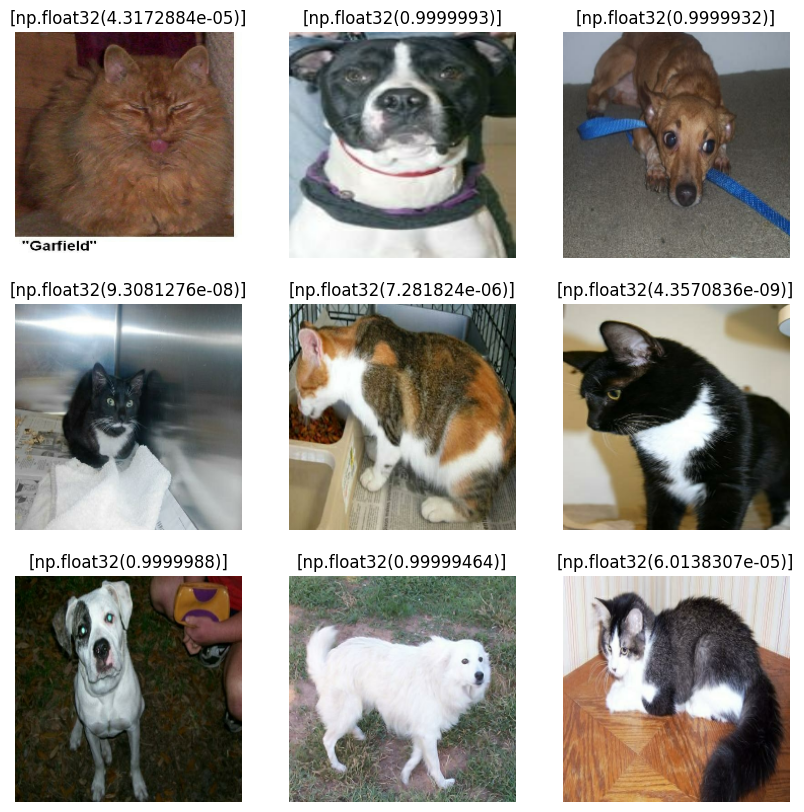

In [87]:
plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title([predictions[i]])
  plt.axis("off")

In [88]:
fetch_and_predict_image("https://uploads.dailydot.com/2018/10/olli-the-polite-cat.jpg?auto=compress&fm=*pjpg*",model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction value: 0.0020 (cat)




*   Transfer learning Model accuracy =  0.9851.
*   Transfer learning + Fine tuned model accuracy = 0.9950.




You may test the model with the fetch_and_predict_image function with any image from the web.

In [90]:
fetch_and_predict_image("https://imgs.search.brave.com/F-R-k3lsjglEwRNGYj55T5MdgxpLTEa3lUIeBTYVufs/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9pbWFn/ZXMudW5zcGxhc2gu/Y29tL3Bob3RvLTE1/MTQ4ODgyODY5NzQt/NmMwM2UyY2ExZGJh/P2ZtPWpwZyZxPTYw/Jnc9MzAwMCZhdXRv/PWZvcm1hdCZmaXQ9/Y3JvcCZpeGxpYj1y/Yi00LjEuMCZpeGlk/PU0zd3hNakEzZkRC/OE1IeHpaV0Z5WTJo/OE1ueDhZMkYwZkdW/dWZEQjhmREI4Zkh3/dw",model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Prediction value: 0.0000 (cat)
